# Exploratory Data Analysis

In [179]:
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
import plotly.graph_objects as go
import torch

In [180]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.data.jet_constituents_data_loading import JetConstL1TriggerDataset
from src.data.event_particles_data_loading import EventPartL1TriggerDataset
from src.data.event_jets_data_loading import EventJetsL1TriggerDataset

Let us start by viewing the features of a generic parquet data file.

In [181]:
file_path = "/run/media/francesco/STORAGE/data_cern_2/Test/ggHbb/ggHbb-NEVENT10000-RS13000010.parquet"

parquet_file = pq.read_schema(file_path)

In [182]:
parquet_file.names

['FullReco_PUPPIPart_PT',
 'FullReco_PUPPIPart_Eta',
 'FullReco_PUPPIPart_Phi',
 'FullReco_PUPPIPart_E',
 'FullReco_PUPPIPart_Charge',
 'FullReco_PUPPIPart_Mass',
 'FullReco_PUPPIPart_PID',
 'FullReco_PUPPIPart_D0',
 'FullReco_PUPPIPart_DZ',
 'FullReco_PUPPIPart_ErrorD0',
 'FullReco_PUPPIPart_ErrorDZ',
 'FullReco_PUPPIPart_fUniqueID',
 'FullReco_PUPPIPart_PuppiW',
 'FullReco_PUPPIPart_IsPU',
 'FullReco_PUPPIPart_IsRecoPU',
 'FullReco_PFPart_PT',
 'FullReco_PFPart_Eta',
 'FullReco_PFPart_Phi',
 'FullReco_PFPart_E',
 'FullReco_PFPart_Charge',
 'FullReco_PFPart_Mass',
 'FullReco_PFPart_PID',
 'FullReco_PFPart_D0',
 'FullReco_PFPart_DZ',
 'FullReco_PFPart_ErrorD0',
 'FullReco_PFPart_ErrorDZ',
 'FullReco_PFPart_fUniqueID',
 'FullReco_PFPart_PuppiW',
 'FullReco_PFPart_IsPU',
 'FullReco_PFPart_IsRecoPU',
 'FullReco_Electron_PT',
 'FullReco_Electron_Eta',
 'FullReco_Electron_Phi',
 'FullReco_Electron_Charge',
 'FullReco_Electron_EhadOverEem',
 'FullReco_Electron_IsolationVar',
 'FullReco_Elect

We are interested in L1-trigger data, in particular on the kinematic features $p_T$, $\eta$ and $\phi$.

## Jet-constituents-level

### minbias

In [183]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [184]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [185]:
print(f"Total jets: {tot_jets}")

Total jets: 3533


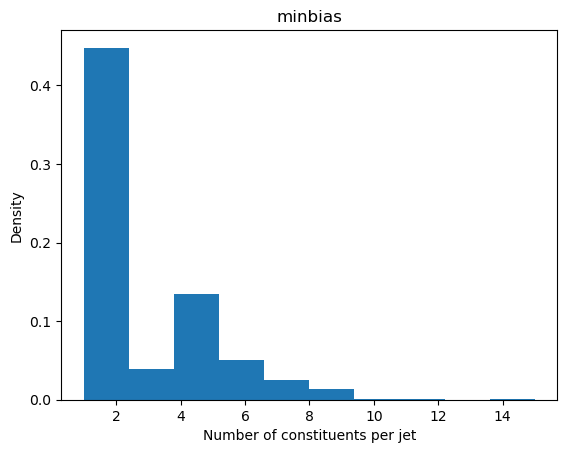

In [186]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

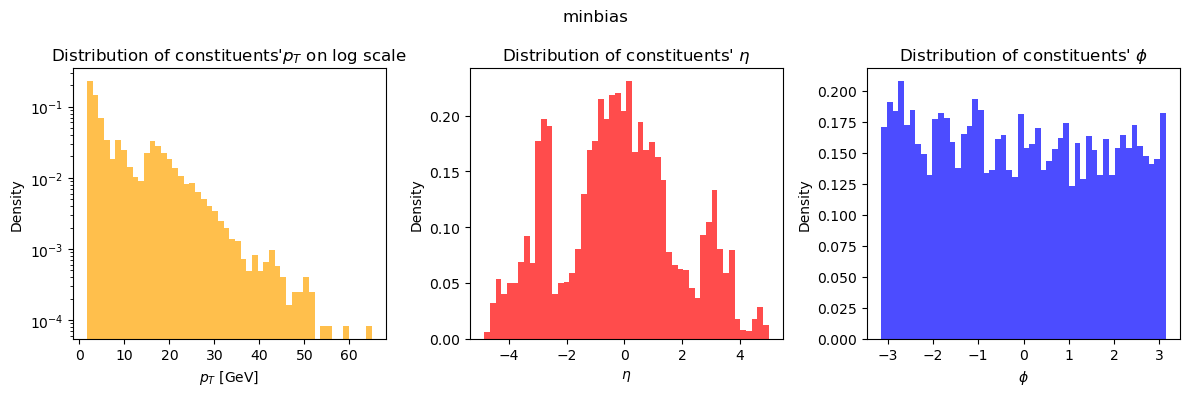

In [187]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [188]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [189]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [190]:
print(f"Total jets: {tot_jets}")

Total jets: 56621


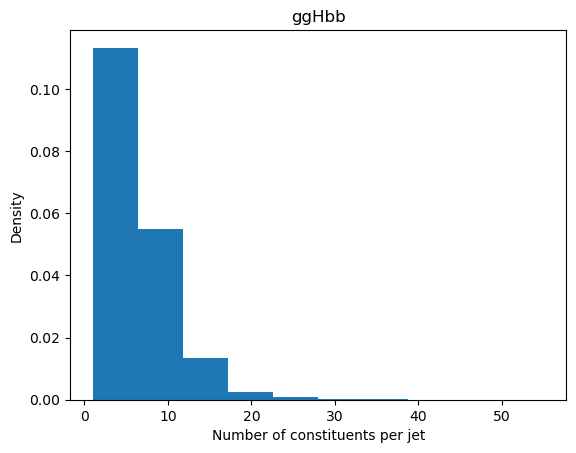

In [191]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

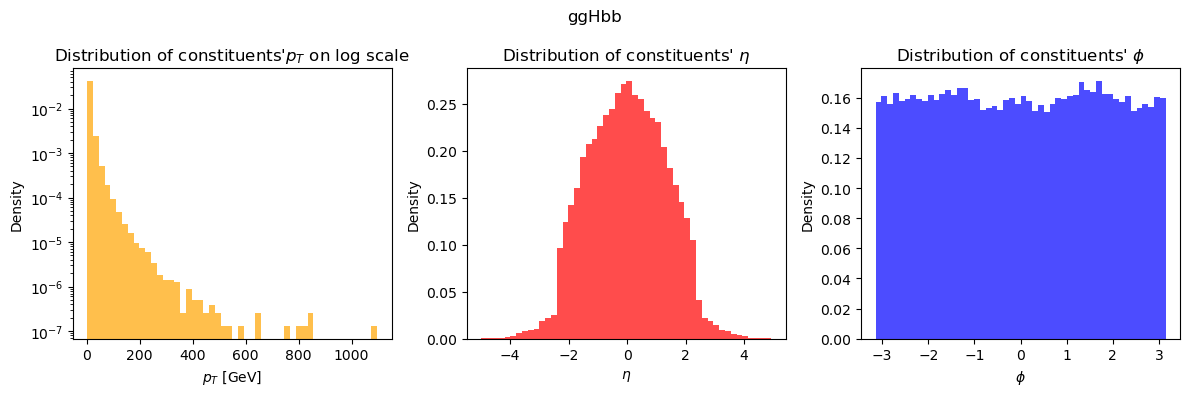

In [192]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [193]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [194]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [195]:
print(f"Total jets: {tot_jets}")

Total jets: 60154


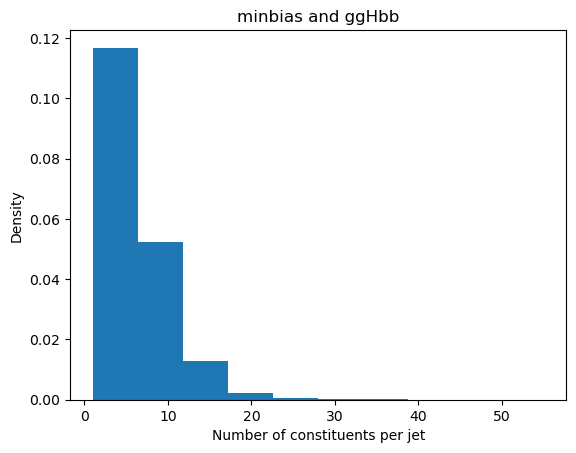

In [196]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

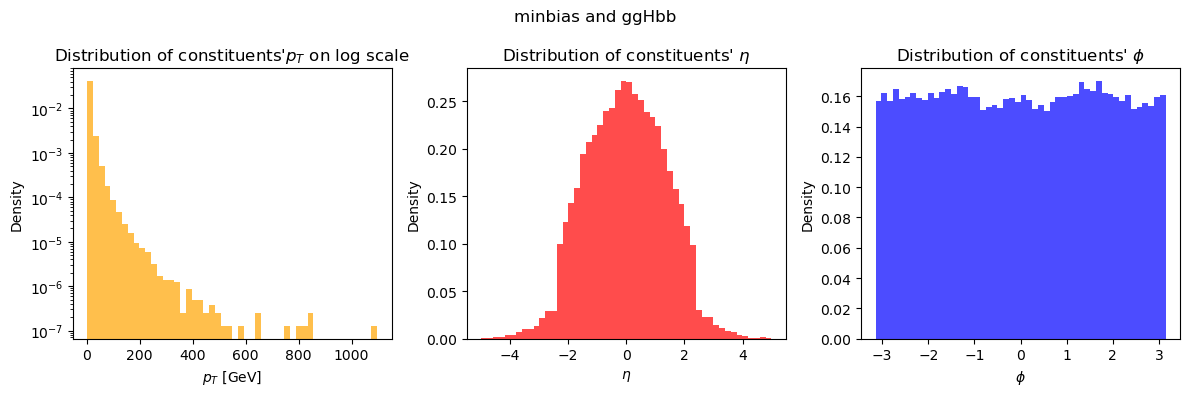

In [197]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

## Event-particles-level

### minbias

In [198]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [199]:
pt = []
eta = []
phi = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [200]:
print(f"Total events: {tot_events}")

Total events: 20000


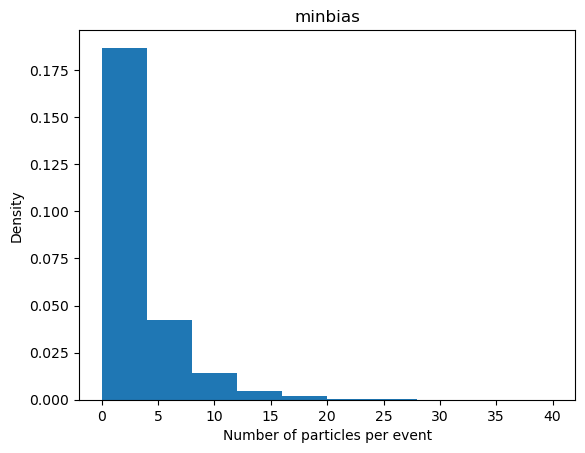

In [201]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

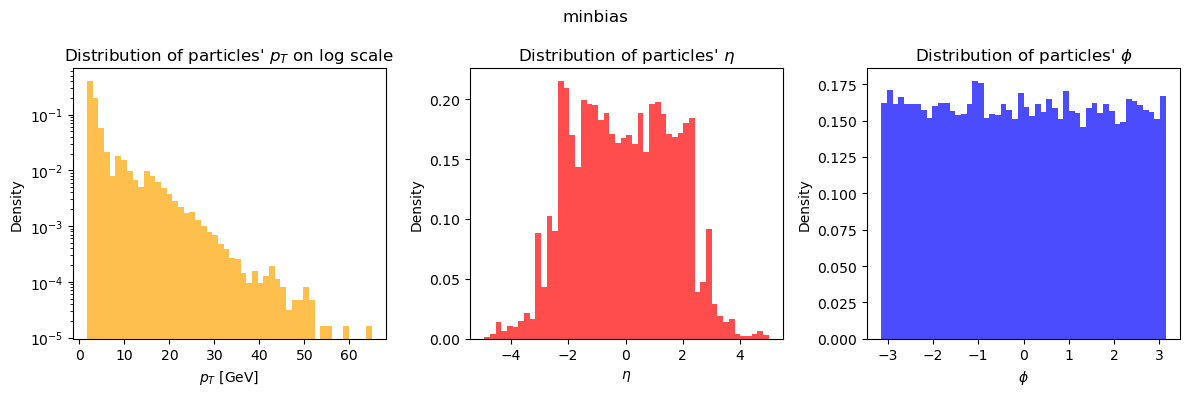

In [202]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of particles' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of particles' $\phi$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [203]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [204]:
pt = []
eta = []
phi = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [205]:
print(f"Total events: {tot_events}")

Total events: 19987


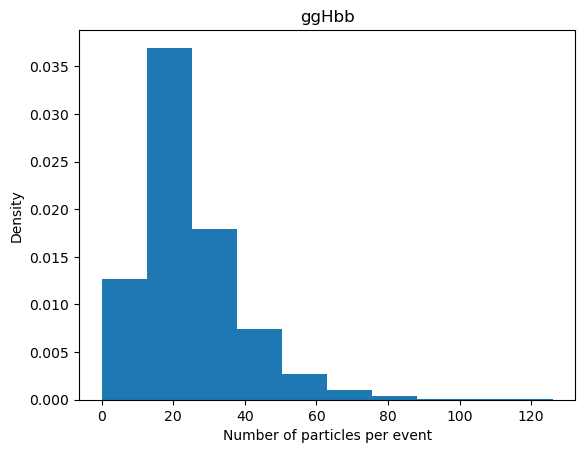

In [206]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

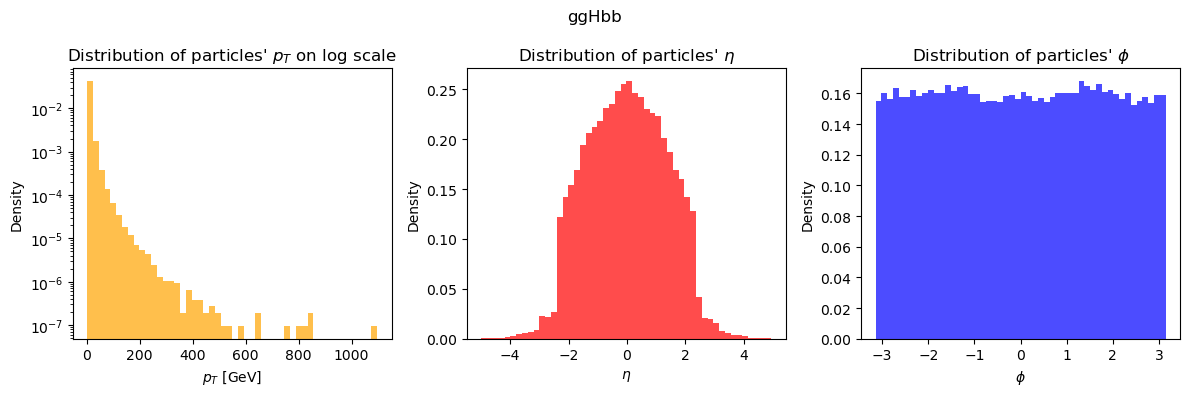

In [207]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of particles' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of particles' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [208]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [209]:
pt = []
eta = []
phi = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [210]:
print(f"Total events: {tot_events}")

Total events: 39987


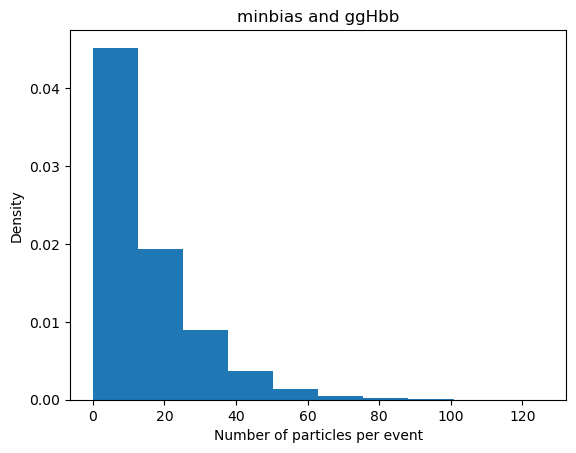

In [211]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

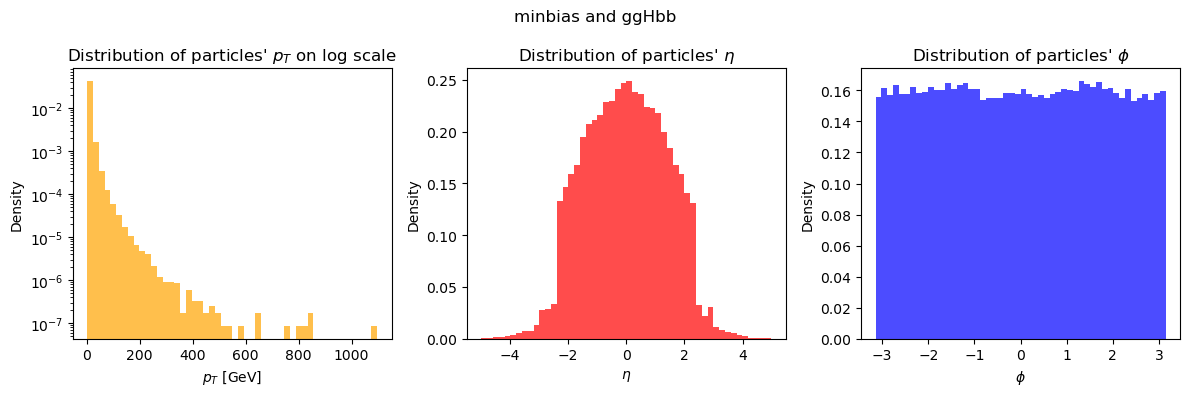

In [212]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of particles' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of particles' $\phi$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

## Event-jets-level

### minbias

In [213]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [214]:
pt = []
eta = []
phi = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [215]:
print(f"Total events: {tot_events}")

Total events: 20000


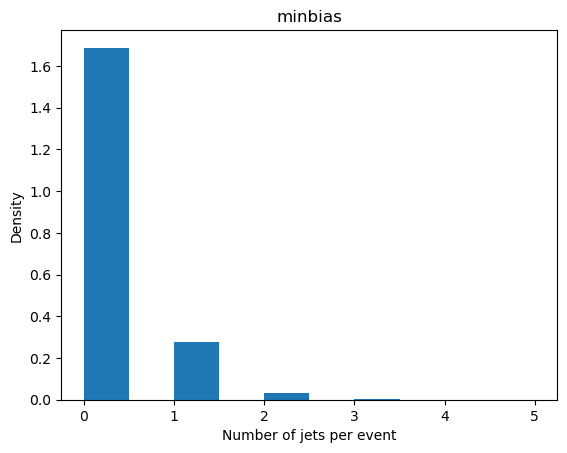

In [216]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

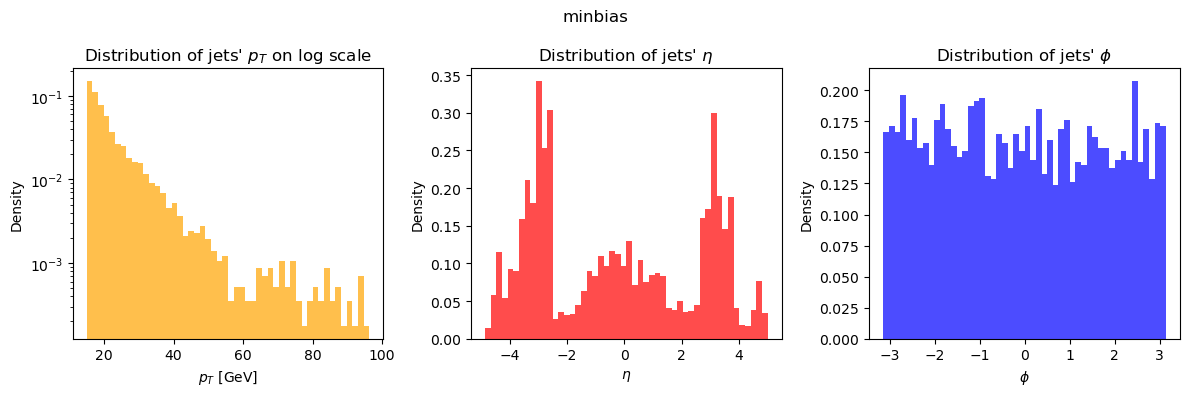

In [217]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of jets' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of jets' $\phi$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [218]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [219]:
pt = []
eta = []
phi = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [220]:
print(f"Total events: {tot_events}")

Total events: 19987


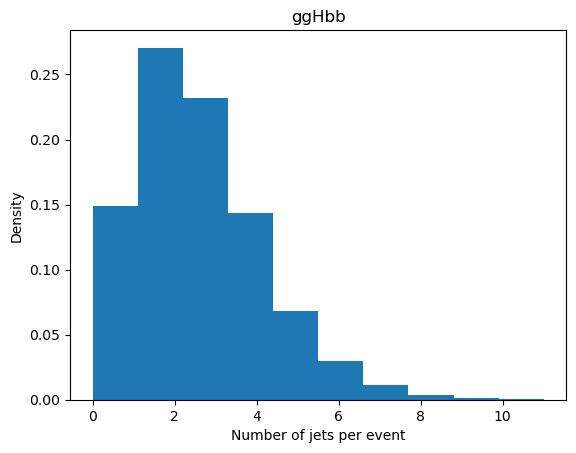

In [221]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

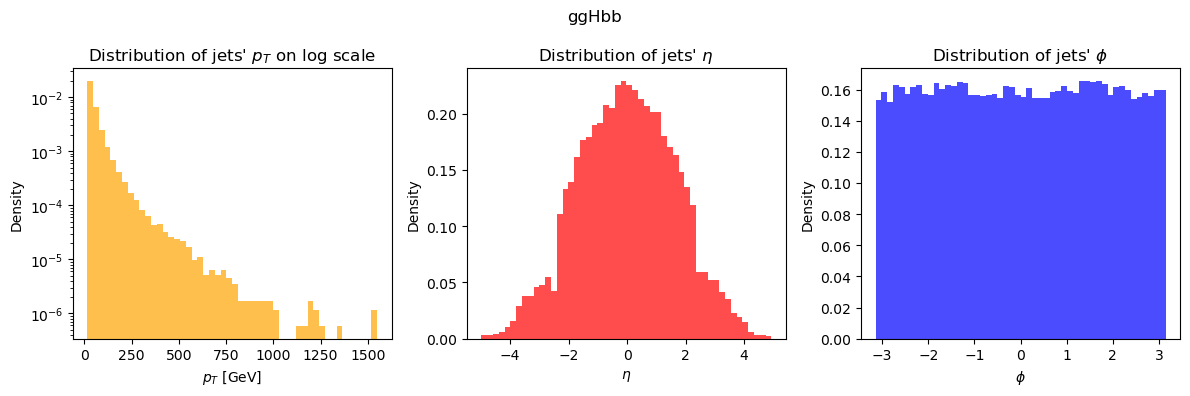

In [222]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of jets' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of jets' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [223]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [224]:
pt = []
eta = []
phi = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [225]:
print(f"Total events: {tot_events}")

Total events: 39987


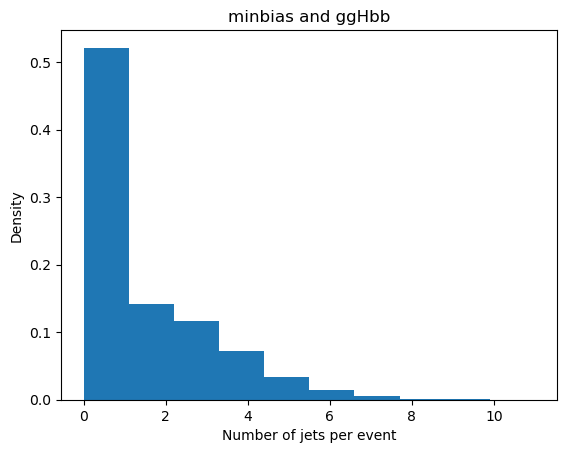

In [226]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

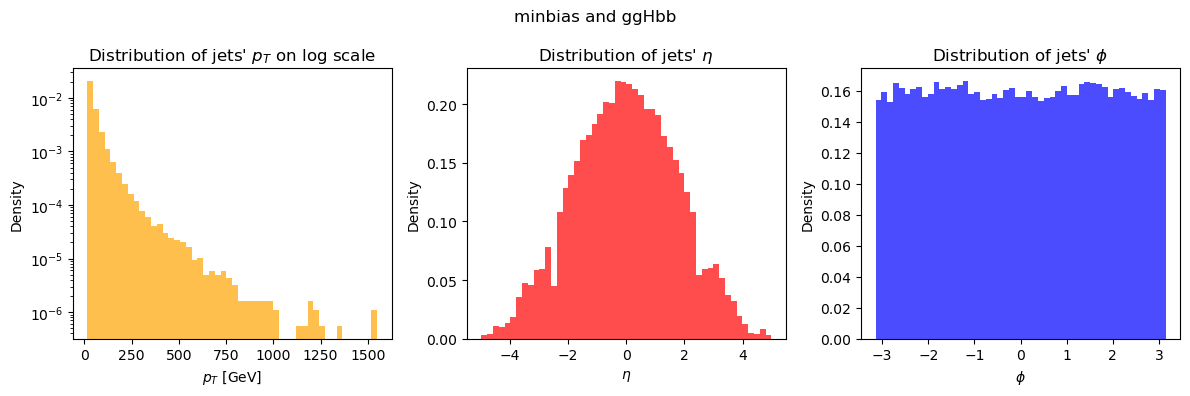

In [227]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of jets' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of jets' $\phi$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()